In [ ]:
colab = True
if colab:
    !git clone https://github.com/mdrs-thiago/PUC_Redes_Neurais
    import os
    os.chdir('/content/PUC_Redes_Neurais/pos_grad/lista 1')

Cloning into 'PUC_Redes_Neurais'...
remote: Enumerating objects: 334, done.
remote: Counting objects: 100% (54/54), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 334 (delta 47), reused 44 (delta 43), pack-reused 280 (from 1)
Receiving objects: 100% (334/334), 4.06 MiB | 10.72 MiB/s, done.
Resolving deltas: 100% (131/131), done.


# Redes Neurais
## 1ª Lista de Exercícios - Classificação de padrões


Estudante: Diego Manuel Jesus Vasquez Levano

Base de dados:

### Para cada item da lista de exercício, não esqueça de fazer uma análise pertinente dos resultados obtidos.

### Guia prático

A lista de exercícios é dividida em 4 partes. Cada questão possui as seguintes seções:

* **Rascunho**: neste espaço, você pode escrever qualquer código ou teste que queira fazer, mas que *não* produza a resposta desejada.

* **Resposta**: deve conter trechos do código que produzam artefatos importantes para a análise de resultados, além de comentários e discussões sobre o item.

Não é necessário seguir esta ordem, mas é *altamente recomendável*. O intuito da lista de exercícios **não** é medir o nível de conhecimento em programação, então não se preocupe se o código não estiver da forma mais polida possível. O principal ponto a ser avaliado é a capacidade crítica de entender os fenômenos atrelados aos resultados obtidos e a discussão de resultados para um problema específico.   

Outros pontos importantes:

1. Fique atento com os hiperparâmetros iniciais desta lista. Dependendo do problema, os valores podem mudar. Para encontrar um conjunto de parâmetros razoáveis, siga o seguinte roteiro:

    * Rode os itens 2.1 e 3.1 com os parâmetros iniciais. Se os dois resultados foram igualmente ruins, modifique os parâmetros do item 3.1 até que o resultado seja relativamente melhor que o 2.1.

    * Após obter esses melhores parâmetros iniciais, rode novamente o item 2.1 com os mesmos hiperparâmetros para uma comparação mais justa.

2. O resultado de um modelo de Redes Neurais geralmente depende da inicialização de seus pesos. Portanto, para cada questão, obtenha um resultado médio de pelo menos 10 rodadas. A recomendação pessoal é de que faça uso do histórico existente da perda (loss) e acurácia para visualização dos resultados, com plot da média e seu intervalo de confiança em função das épocas.

In [ ]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from time import sleep
import requests

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from utils import CustomDataset, transform_data, plot_confusion_matrix

from typing import Tuple, Dict, List
from tqdm import tqdm

In [ ]:
def accuracy(y_pred: torch.Tensor, y_test: torch.Tensor) -> float:
    """
    Computes the accuracy of a PyTorch model given the outputs and labels.

    Parameters:
        outputs (torch.Tensor): The model outputs.
        labels (torch.Tensor): The true labels.

    Returns:
        float: The accuracy of the model.
    """

    _, predictions = torch.max(y_pred, dim=1)
    correct = torch.sum(predictions == y_test)
    accuracy = correct.float() / y_test.size(0)
    acc = torch.round(accuracy * 100)

    return acc

def binary_acc(y_pred: torch.Tensor, y_test: torch.Tensor) -> float:
    """
    Computes the binary accuracy of a PyTorch model given the outputs and labels.

    Parameters:
        outputs (torch.Tensor): The model outputs.
        labels (torch.Tensor): The true labels.

    Returns:
        float: The accuracy of the model.
    """

    predictions = torch.round(torch.sigmoid(y_pred))
    correct = torch.sum(predictions == y_test)
    accuracy = correct.float() / y_test.size(0)
    acc = torch.round(accuracy * 100)

    return acc

In [ ]:
def evaluate(model: torch.nn.Module, val_set: Tuple[torch.tensor, torch.tensor],
            criterion: torch.nn.Module, binary:bool =True) -> Tuple[torch.tensor, float, float]:
    """
    Evaluates a Pytorch model on a given dataset.
    Parameters:
    model (torch.nn.Module): The model to be evaluated
    data (tuple): A tuple containing the data and labels
    criterion (torch.nn.Module): The loss function to be used
    binary (bool): Boolean indicating whether the task is binary classification or not. Default: True
    Returns:
    tuple: A tuple containing predicted labels, loss, and accuracy
    """

    X = val_set.X_data
    y = val_set.y_data

    with torch.no_grad():
        y_pred = model(X)
    loss = criterion(y_pred, y)
    if binary:
        acc = binary_acc(y_pred, y)
    else:
        acc = accuracy(y_pred, y)
    y_pred = torch.argmax(y_pred, dim=1)

    return y_pred, loss.item(), acc.item()


In [ ]:
def train(model: torch.nn.Module , train_loader: torch.utils.data.DataLoader,
         val_set: Tuple[torch.Tensor, torch.Tensor], epochs: int, device: torch.device,
         lr: float, binary: bool = True, skip: int = 1) -> Tuple[Dict[str, List[float]], torch.Tensor]:
    """
    Trains a Pytorch model on a given training data.

    Parameters:
    model (torch.nn.Module): The model to be trained
    train_loader (DataLoader): The training data in the form of a Pytorch DataLoader
    val_set (tuple): A tuple containing the validation data and labels
    epochs (int): The number of times the training data should be passed through the model
    device (str or torch.device): The device on which to perform the computations (e.g. 'cpu' or 'cuda')
    lr (float): The learning rate for the optimizer
    binary (bool): Boolean indicating whether the task is binary classification or not. Default: True
    skip (int): The number of epochs after which the training and validation results will be printed. Default: 1

    Returns:
    tuple: A tuple containing the training history and the predicted labels after training
    """

    if binary:
        criterion = nn.BCEWithLogitsLoss()
    else:
        criterion = nn.CrossEntropyLoss()


    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    history = {'acc_train' : [], 'loss_train': [], 'acc_val': [], 'loss_val': []}

    for e in tqdm(range(1, epochs+1)):

        y_hat = np.array([])

        train_epoch_loss = 0
        train_epoch_acc = 0
        model.train()
        for X_train_batch, y_train_batch in train_loader:
            X, y = X_train_batch.to(device), y_train_batch.to(device)
            optimizer.zero_grad()

            y_pred = model(X)

            loss = criterion(y_pred, y)
            if binary:
                acc = binary_acc(y_pred,y)
            else:
                acc = accuracy(y_pred, y)

            loss.backward()
            optimizer.step()

            train_epoch_loss += loss.item()
            train_epoch_acc += acc.item()
            y_p = torch.argmax(y_pred, dim=1)
            y_hat = np.concatenate((y_hat, y_p))


        model.eval()
        _, val_loss, val_acc = evaluate(model, val_set, criterion, binary=binary)

        history['acc_train'].append(train_epoch_acc/len(train_loader))
        history['loss_train'].append(train_epoch_loss/len(train_loader))
        history['acc_val'].append(val_acc)
        history['loss_val'].append(val_loss)

        if e%skip == 0:
            print(f'Epoch {e+0:03}: | Train Loss: {train_epoch_loss/len(train_loader):.3f} | Val Loss: {val_loss:.4f} | Train Acc: {train_epoch_acc/len(train_loader):.4f}| Val Acc: {val_acc:.4f}')
    return history, y_hat

In [ ]:
class NeuralNetwork(torch.nn.Module):
  '''
  Objeto criado para facilitar o desenvolvimento dos scripts das aulas práticas.
  Opção alternativa à criação externa fdo modelo. Basicamente serve como um
  'agregador'  de trechos comuns para a criação do modelo. Por exemplo, ao invés
  de gastar n+1 linhas para a criação de um modelo com n camadas, podemos criar
  o mesmo modelo com apenas uma linha.

  Parâmetros de entrada:
  - hidden_neurons: Lista com a quantidade de neurônios na camada escondida.
  - hidden_activation: Função de ativação para cada camada escondida. Aceita
  como parâmetro string ou lista. Caso o parâmetro receba string, então a mesma
  função de ativação é utilizada para todas as camadas escondidas. Caso seja uma
  lista, cada camada terá sua propria função de ativação definida pela lista.
  - output_activation: Função de ativação para a camada de saída.
  - lr: Taxa de aprendizado
  - n_input: Tamanho do vetor de entrada.
  - n_output: Saída do modelo.
  '''
  def __init__(self,hidden_neurons = 4, hidden_activation = 'relu', output_activation='softmax', lr = 0.05, n_input = 1, n_output = 1):
    super(NeuralNetwork, self).__init__()

    self.activations = {'relu': nn.ReLU(), 'sigmoid':nn.Sigmoid(), 'softmax':nn.Softmax()}

    self.fc1 = nn.Linear(n_input, hidden_neurons)
    self.ha = self.activations[hidden_activation]
    self.fc2 = nn.Linear(hidden_neurons, n_output)

  def forward(self,x):
    h = self.fc1(x)
    h1 = self.ha(h)
    y = self.fc2(h1)
    return y

  def predict(self, x, binary=True):
    y_hat = self.forward(x)

    if binary:
      y_pred = torch.round(torch.sigmoid(y_hat))
      y_pred = y_pred.detach().numpy()
    else:
      y_pred = torch.argmax(y_hat, dim=1)

    return y_pred

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Preparação dos dados

Não esqueça de verificar o path para a pasta. Mude também o filename, de acordo com a base de dados. Esta parte é necessária para garantir que as colunas sejam corretamente identificadas de acordo com a natureza dos dados.

In [ ]:
dataset_name = 'analise_credito'
dataset_path = f'https://raw.githubusercontent.com/mdrs-thiago/PUC_Redes_Neurais/main/datasets/c_{dataset_name}.csv'
info_path = f'https://raw.githubusercontent.com/mdrs-thiago/PUC_Redes_Neurais/main/datasets/data_info/{dataset_name}/data_info.json'
dataset = pd.read_csv(dataset_path)

In [ ]:
resp = requests.get(info_path)
info = json.loads(resp.text)

In [ ]:
for col, k in info.items():
    if k == 'categorical':
        dataset[col] = dataset[col].astype(object)

In [ ]:
for i in dataset.dtypes.items():
    print(i)

('ESTC', dtype('O'))
('NDEP', dtype('int64'))
('RENDA', dtype('int64'))
('TIPOR', dtype('O'))
('VBEM', dtype('int64'))
('NPARC', dtype('int64'))
('VPARC', dtype('int64'))
('TEL', dtype('O'))
('IDADE', dtype('int64'))
('RESMS', dtype('int64'))
('ENTRADA', dtype('int64'))
('target', dtype('int64'))


## Parte I - Compreensão do problema e análise de variáveis

Total: 0,5 pts.


1)	Neste primeiro momento, iremos verificar a qualidade dos dados. Verifique se os dados estão aptos para o treinamento de Redes Neurais (i.e., verifique a existência de dados nulos, atributos de identificação ou duplicados). Implemente o código que execute as técnicas necessárias e discuta o racional utilizado para o tratamento de dados.

Rascunho

In [ ]:
dataset.head()

,ESTC,NDEP,RENDA,TIPOR,VBEM,NPARC,VPARC,TEL,IDADE,RESMS,ENTRADA,target
0,1,0,360,0,313,9,52,0,25,48,0,1
1,0,0,350,1,468,10,65,0,33,6,0,1
2,0,0,1100,0,829,9,125,0,56,48,0,1
3,0,0,3000,0,552,12,76,1,31,60,0,1
4,1,0,1000,0,809,12,111,0,24,7,0,1


In [ ]:
# Columnas Nan en general, revisando que no tengan valores null, igualmente para valores
# de tipo categoricos es buena oportunidad revisar que los valores que tome sean consistentes
# y las variables numericas que manejemos de forma correcta los outliers y valores atipicos
dataset.isna().sum()

,0
ESTC,0
NDEP,0
RENDA,0
TIPOR,0
VBEM,0
NPARC,0
VPARC,0
TEL,0
IDADE,0
RESMS,0


In [ ]:
var_cat = ['ESTC', 'TIPOR', 'TEL']
var_num = list(set(dataset.columns) - set(var_cat) - set(['target']))

In [ ]:
var_num

['VPARC', 'VBEM', 'ENTRADA', 'NPARC', 'RESMS', 'NDEP', 'IDADE', 'RENDA']

In [ ]:
# Valores posibles para variables categoricas, tienen sentido. Ya que tienen valores esperados
# los cuales muestra que no toman valores fuera de los esperados, por lo que no requiere limpieza
for col in dataset.select_dtypes(include=["object", "category"]):
  print(col, dataset[col].value_counts())

ESTC ESTC
0    834
1    601
3     37
2     28
Name: count, dtype: int64
TIPOR TIPOR
0    832
1    668
Name: count, dtype: int64
TEL TEL
0    1299
1     201
Name: count, dtype: int64


In [ ]:
dataset.describe()

,NDEP,RENDA,VBEM,NPARC,VPARC,IDADE,RESMS,ENTRADA,target
count,1500.000000,1500.00000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,0.126667,984.51200,562.031333,8.392667,102.247333,41.210667,31.528667,32.255333,0.476667
std,0.572865,905.53292,265.690646,3.609131,62.987325,13.202266,52.662099,94.307614,0.499622
min,0.000000,300.00000,300.000000,1.000000,50.000000,19.000000,0.000000,0.000000,0.000000
25%,0.000000,467.50000,410.000000,6.000000,66.000000,31.000000,6.000000,0.000000,0.000000
50%,0.000000,650.00000,490.000000,10.000000,83.000000,39.000000,6.000000,0.000000,0.000000
75%,0.000000,1200.00000,618.000000,10.000000,118.000000,52.000000,48.000000,0.000000,1.000000
max,7.000000,8000.00000,4000.000000,24.000000,711.000000,70.000000,420.000000,1300.000000,1.000000


array([[<Axes: title={'center': 'VPARC'}>,
        <Axes: title={'center': 'VBEM'}>,
        <Axes: title={'center': 'ENTRADA'}>],
       [<Axes: title={'center': 'NPARC'}>,
        <Axes: title={'center': 'RESMS'}>,
        <Axes: title={'center': 'NDEP'}>],
       [<Axes: title={'center': 'IDADE'}>,
        <Axes: title={'center': 'RENDA'}>, <Axes: >]], dtype=object)

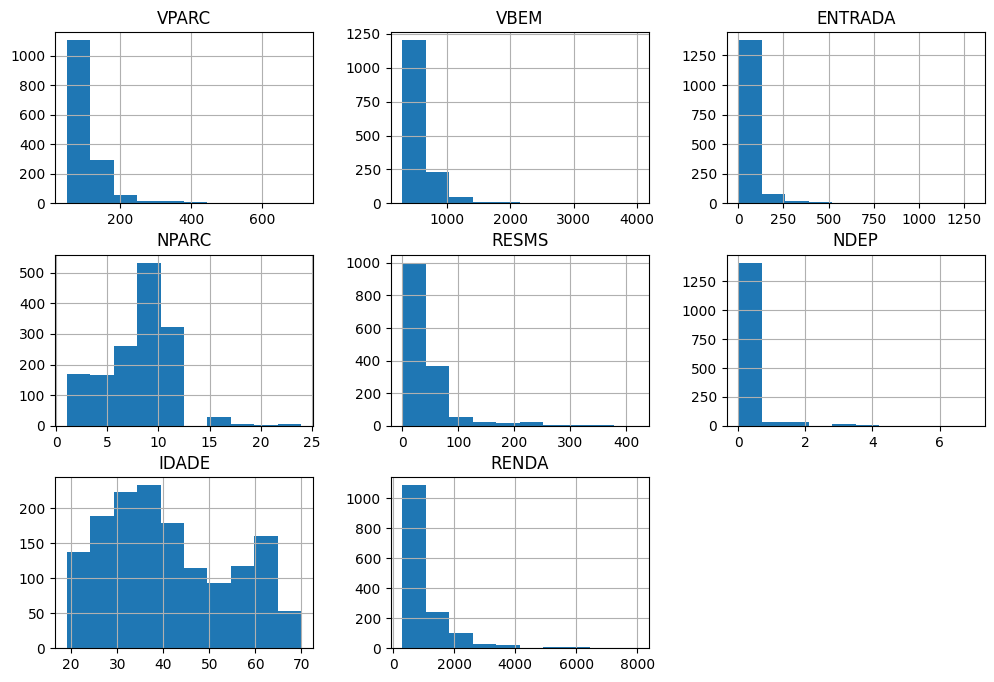

In [ ]:
dataset[var_num].hist(figsize=(12, 8))

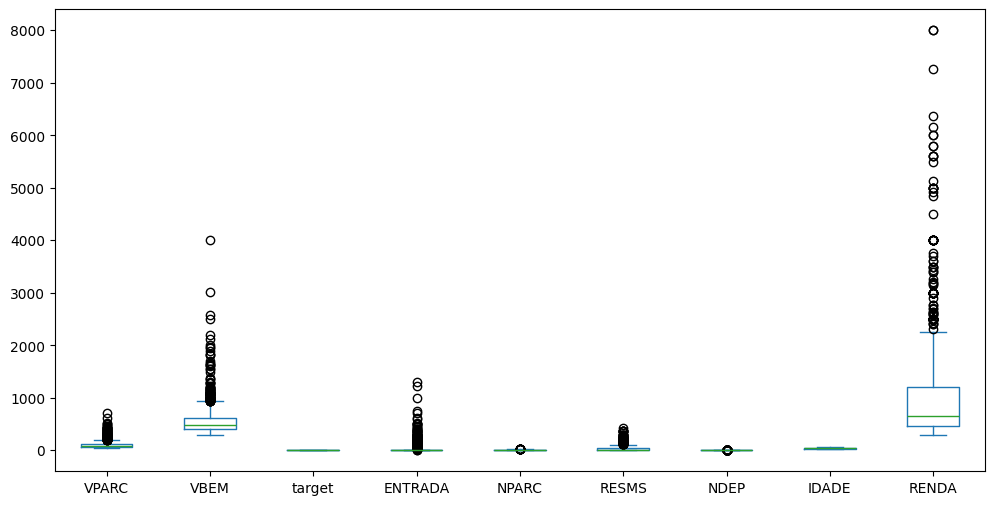

In [ ]:
# En este caso de aca
import matplotlib.pyplot as plt

dataset[var_num].plot(kind="box", figsize=(12, 6))
plt.show()

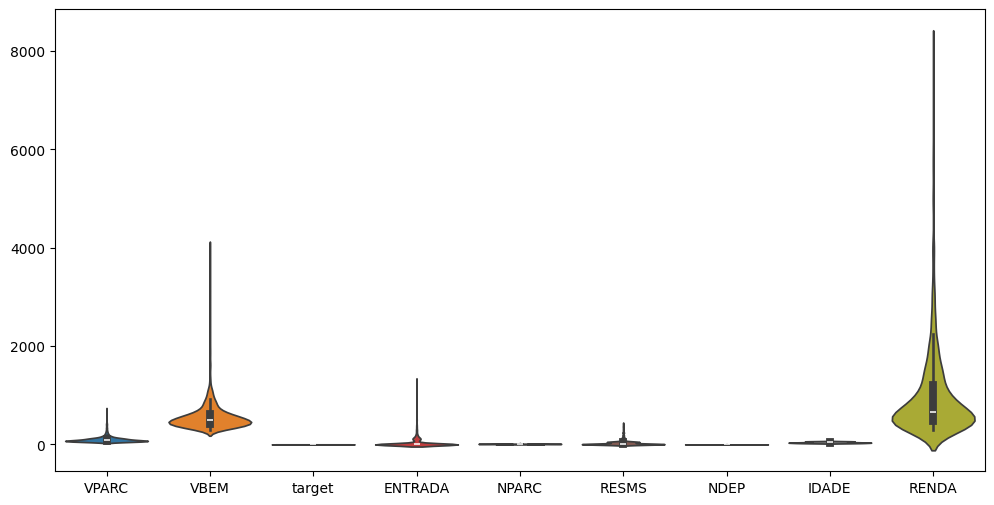

In [ ]:
import seaborn as sns

plt.figure(figsize=(12,6))
sns.violinplot(data=dataset[var_num])
plt.show()

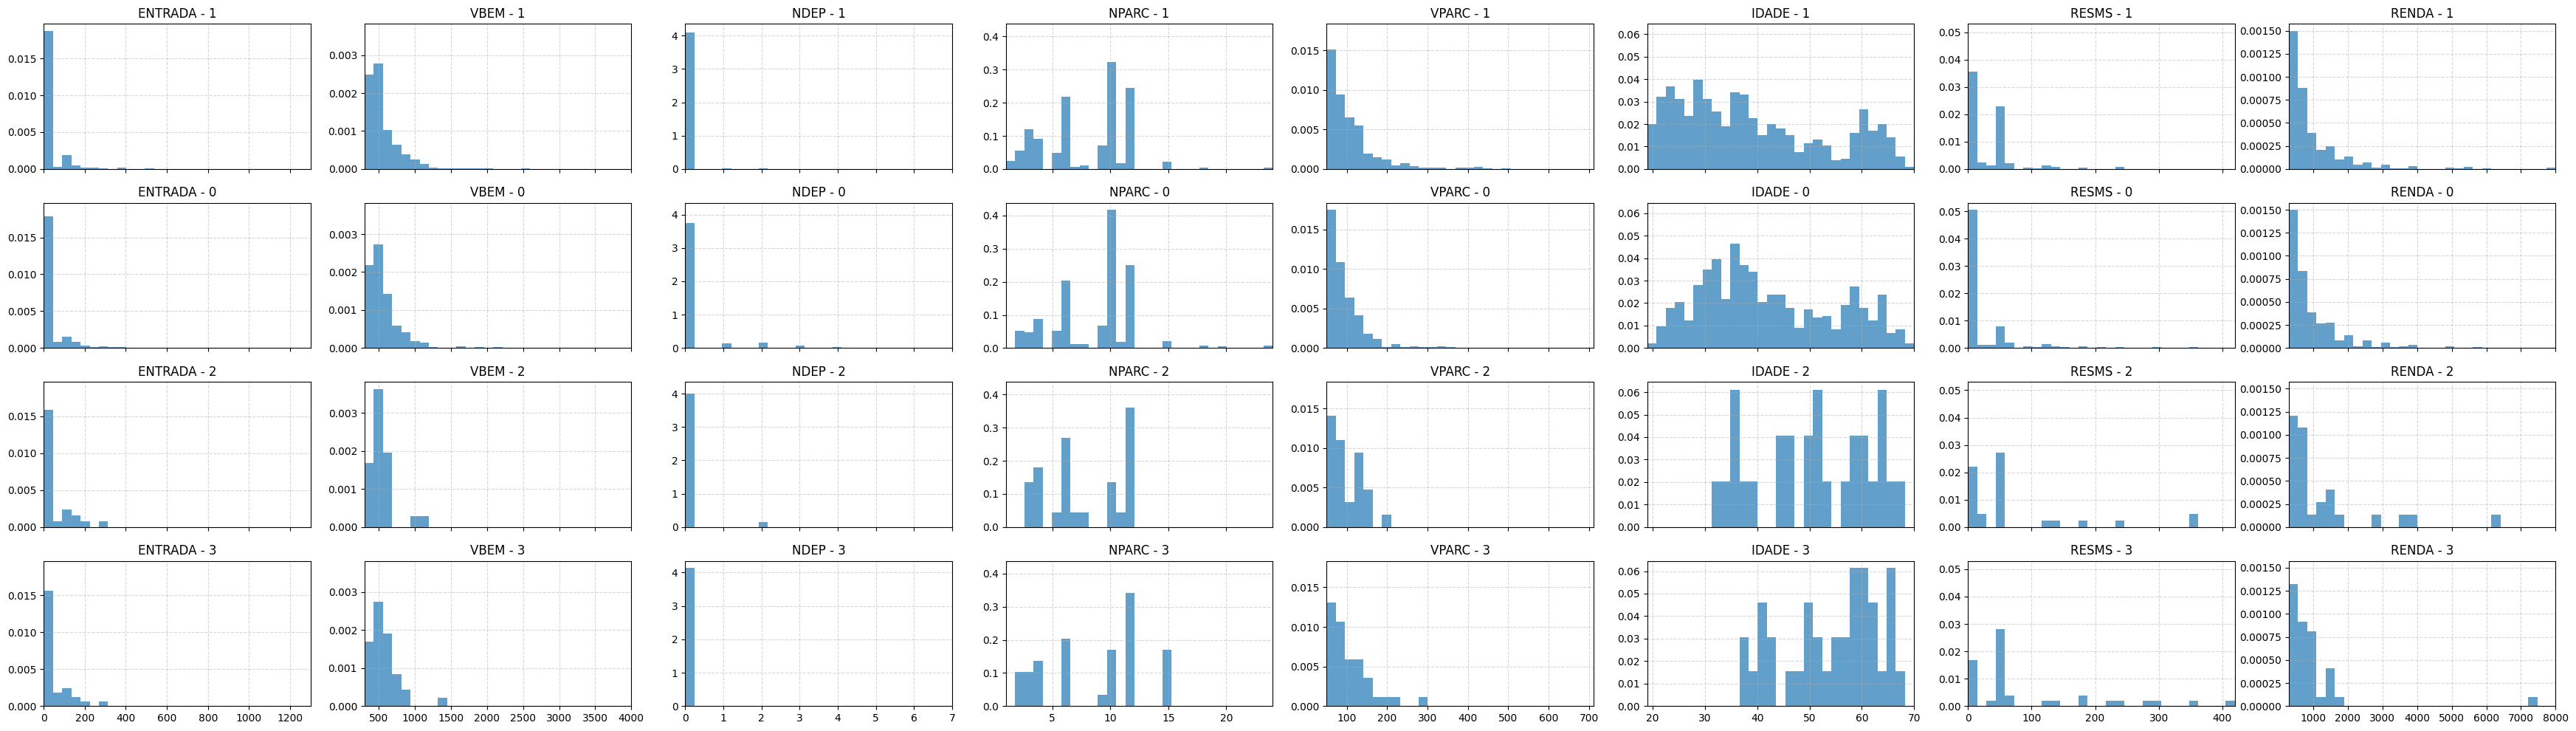

In [49]:
# Analizando el comportamiento de las distribucion de los datos

'''

Para este caso vemos que si revisamos como se comportan las las variables numericas
con las variables categoricas vemos que la mayoria tiene un comportamiento similar en distribucion,
con ligeros cambios entorno a su comportamiento.

Por ejemplo en el caso de NPARC que
hay personas que obtaron por un numero de 15 parcelas es un poco mas frecuente el la categoria
3 del estado civil, lo que muestran una distribucion con un cambio significativo, y podria ser
util para el modelo.

Tambien, la distribucion de edades es distinta segun el estado civil, un hecho logico y que pueda ser relevante
para el modelo, el cual es bastante diferente entre las diferentes categoricas, cambiando en forma y en modas

en el RESMS vemos uqe si vamos de 0 1 2 y 3, se aprecia que la tendencia que inicia de la mayoria a no tener
tiempo de moradia, se empieza a desplazar la tendencia a la derecha, lo que muestra que la gente tiene a morar mas tiempo

Por otro lado NPARC tambien muestra cambios ligeros en la distrinucion entre las diferentes categorias, pero el cambio es bajo

La renda tambien cambia su distribucion segun el estado civil, lo cual muestra que tiende a agruparse mas hacia la moda en cero
para los grupos 2 y 3, y menos para los grupos 0 y 1

Resumo:

Muestra de interaccion fuerte: IDADE
Muestra de interaccion Media: NPARC
Muestra de interaccion Media-baja: Renda,
Muestra de interaccion baja: RESMS
Muestra de interaccion dEBIL (casi no notoria): Las otras categorias

'''

import numpy as np
import matplotlib.pyplot as plt

cols = var_num[:]
categorias = dataset['ESTC'].unique()

fig, axes = plt.subplots(
    len(categorias),
    len(cols),
    figsize=(35, 10),
    sharex='col',
    sharey='col'
)

for j, col in enumerate(cols):
    xmin = dataset[col].min()
    xmax = dataset[col].max()
    bins = np.linspace(xmin, xmax, 30)

    for i, cat in enumerate(categorias):
        ax = axes[i, j]

        data = dataset[dataset['ESTC'] == cat][col]
        ax.hist(data, bins=bins, alpha=0.7, density=True)

        ax.set_xlim(xmin, xmax)
        ax.set_title(f'{col} - {cat}')
        ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

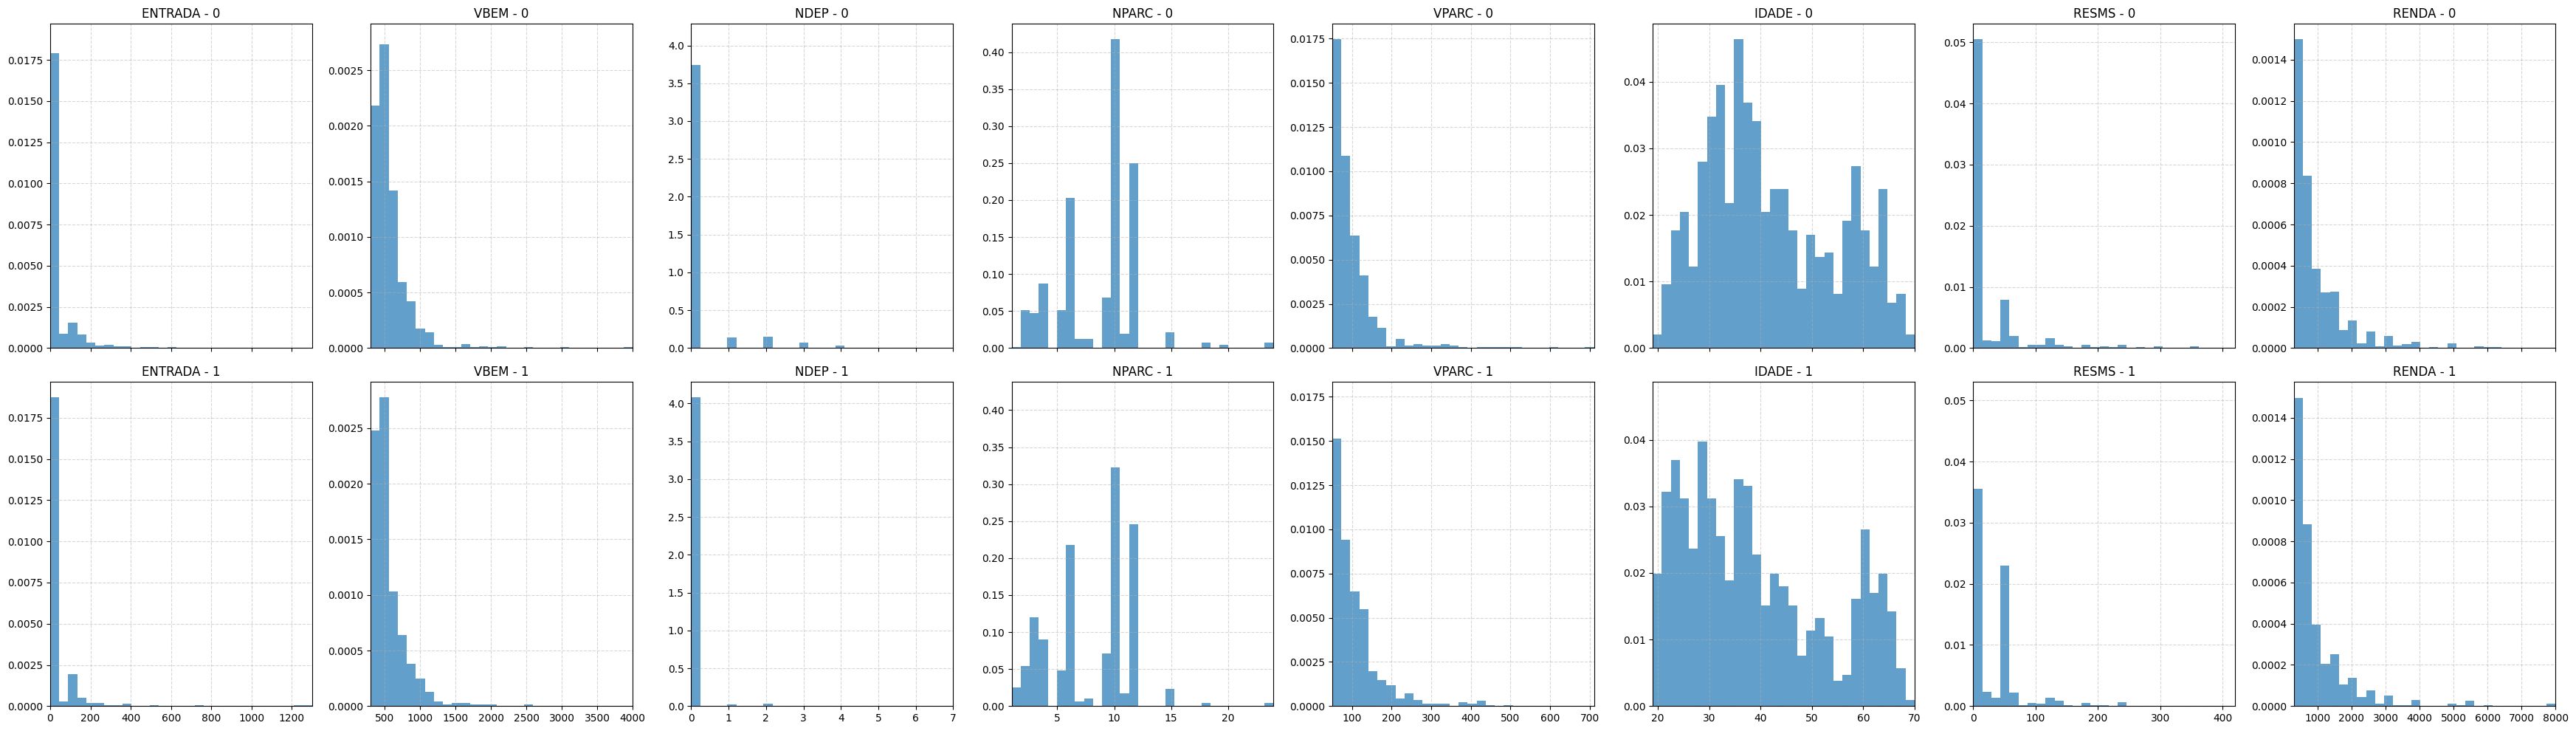

In [47]:
'''
Ahora revisando para la variable TIPOR (Tipo de Residencia)

Vemos que varias variables hay menos cambios o interacciones en la distribucion en estas dos categorias
Puede deberse a que la variable esta mejor balanceada. Sin embargo, tambien se ve cambios en la distribucion de la
edad, donde la moda principal ha sufrido un descolocamiento como se ve en el grafico, siendo menor en la categoria 1 que en la categoria 2,
igualmente para RESMS, que las modas son mas balanceadas en la categoria 1, en cambio en su categoria 0 es mucho mas predominante el 0 (no tener tiempo de moradia)


Resumo:

Muestra de interaccion Media - baja: IDADE,
Muestra de interaccion baja: NPARC, RESMS,
Muestra de interaccion muy dEBIL (casi no notoria): las demas

'''
import numpy as np
import matplotlib.pyplot as plt

cols = var_num[:]
categorias = dataset['TIPOR'].unique()

fig, axes = plt.subplots(
    len(categorias),
    len(cols),
    figsize=(35, 10),
    sharex='col',
    sharey='col'
)

for j, col in enumerate(cols):
    xmin = dataset[col].min()
    xmax = dataset[col].max()
    bins = np.linspace(xmin, xmax, 30)

    for i, cat in enumerate(categorias):
        ax = axes[i, j]

        data = dataset[dataset['TIPOR'] == cat][col]
        ax.hist(data, bins=bins, alpha=0.7, density=True)

        ax.set_xlim(xmin, xmax)
        ax.set_title(f'{col} - {cat}')
        ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

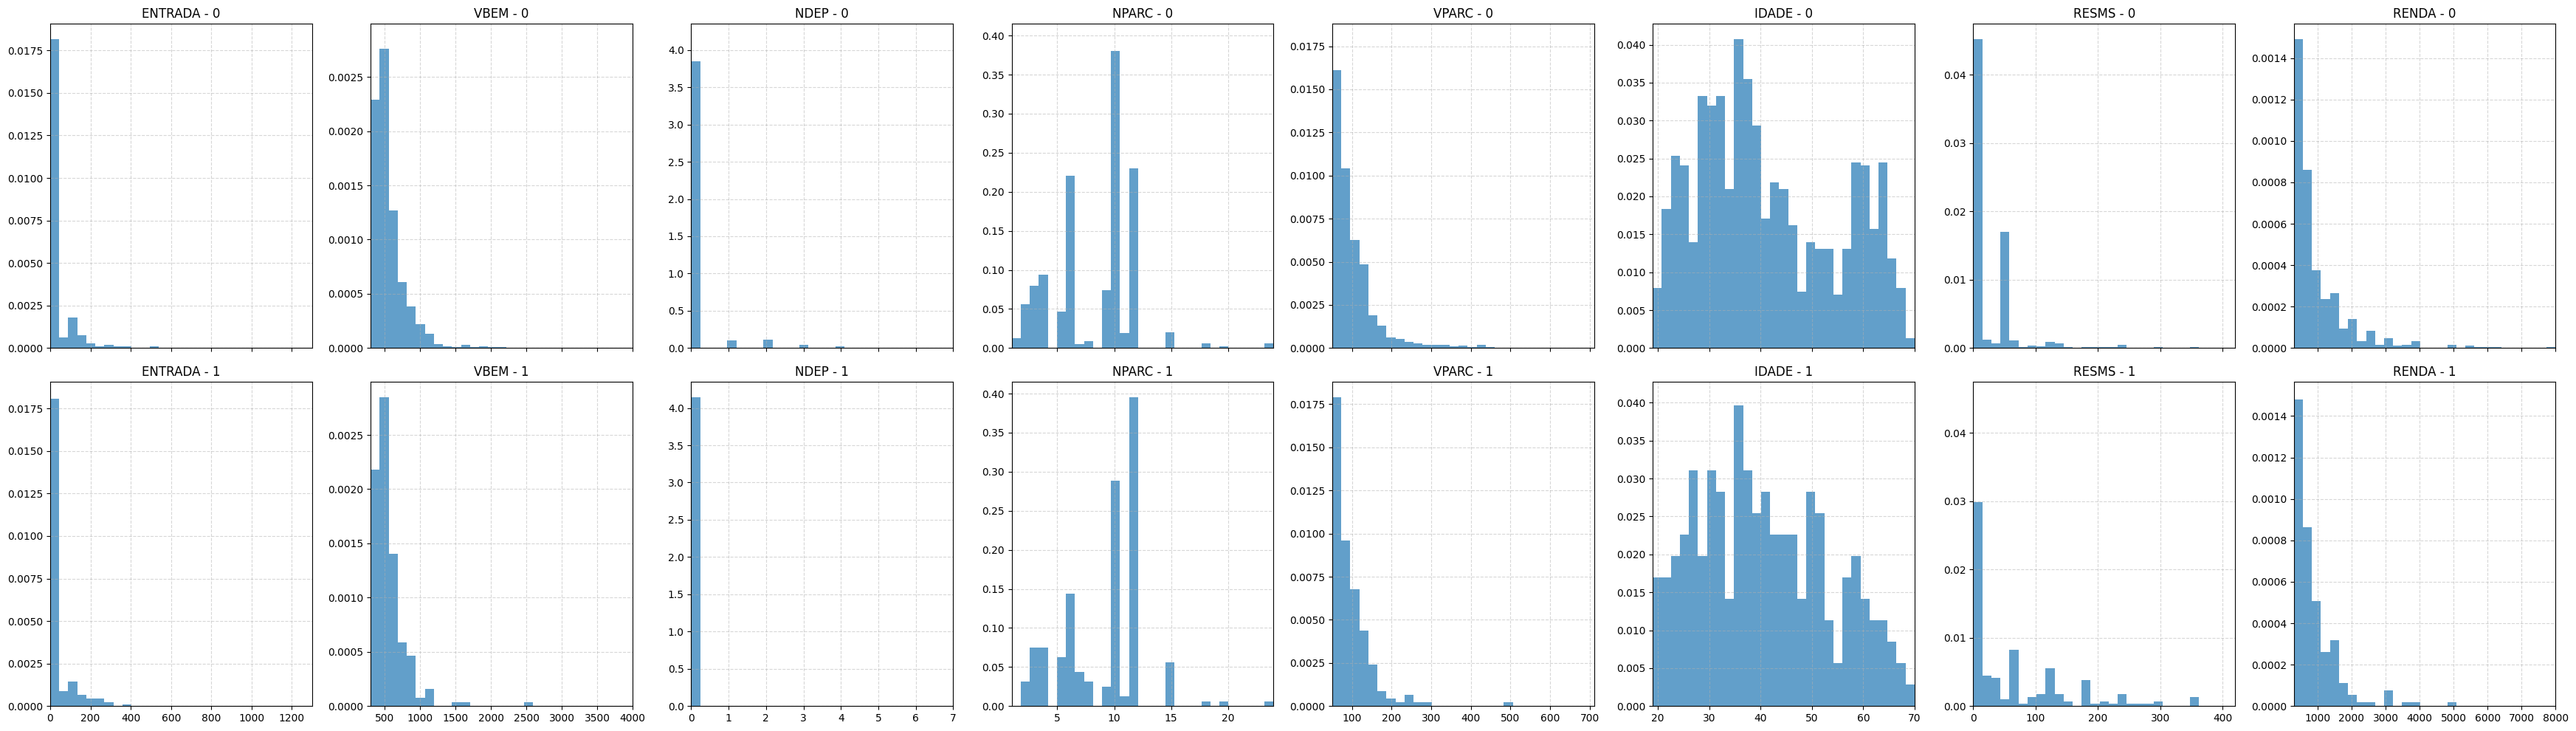

In [48]:
'''
Ahora revisando para la variable TIPOR (Tipo de Residencia)

Vemos que varias variables hay menos cambios o interacciones en la distribucion en estas dos categorias
Puede deberse a que la variable esta mejor balanceada. Sin embargo, tambien se ve cambios en la distribucion de la
NPARC, donde las dos modas de la categoria 0 se han juntado mas a formar una sola en 1, pero el cambio no es tan grande
igualmente para RESMS, que las modas son mas balanceadas en la categoria 1, a su vez tambien la segunda ya no es tan notora,
mostrando que los datos estan mas esparcidos.


Resumo:

Muestra de interaccion Baja: NPARC, RESMS
Muestra de interaccion muy dEBIL (casi no notoria): Las demas

'''
import numpy as np
import matplotlib.pyplot as plt

cols = var_num[:]
categorias = dataset['TEL'].unique()

fig, axes = plt.subplots(
    len(categorias),
    len(cols),
    figsize=(35, 10),
    sharex='col',
    sharey='col'
)

for j, col in enumerate(cols):
    xmin = dataset[col].min()
    xmax = dataset[col].max()
    bins = np.linspace(xmin, xmax, 30)

    for i, cat in enumerate(categorias):
        ax = axes[i, j]

        data = dataset[dataset['TEL'] == cat][col]
        ax.hist(data, bins=bins, alpha=0.7, density=True)

        ax.set_xlim(xmin, xmax)
        ax.set_title(f'{col} - {cat}')
        ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
## Analisis para target 1

Resposta

2) Utilize técnicas de seleção de variáveis e visualização de gráficos para compreender melhor a relação entre as variáveis do problema. Avalie e discuta os resultados obtidos.

Rascunho

Resposta

In [ ]:
#sns.pairplot(dataset, hue="target", diag_kind="hist")

## Parte II. Treinamento do modelo de Rede Neural - Baseline e Efeito da Normalização

Total: 1,5 pts.

1)	Neste momento, iremos fazer a primeira avaliação de resultados do modelo MLP. Com base no que foi aprendido em sala de aula, escolha um valor inicial para os hiperparâmetros `lr` (taxa de aprendizado), `epochs` (número de épocas), `hidden_neurons` (número de neurônios na camada escondida) e `batch_size` (tamanho do lote), justificando sua escolha. Faça o treinamento e responda observando o resultado do treinamento: o modelo foi capaz de aprender? O que pode ser possível inferir sobre a capacidade de generalização?

#### Rascunho

In [ ]:
new_df = transform_data(dataset, normalize=False)
#new_df.head()

In [ ]:
new_df.head()

,ESTC,NDEP,RENDA,TIPOR,VBEM,NPARC,VPARC,TEL,IDADE,RESMS,ENTRADA,target
0,1,0,360,0,313,9,52,0,25,48,0,1
1,0,0,350,1,468,10,65,0,33,6,0,1
2,0,0,1100,0,829,9,125,0,56,48,0,1
3,0,0,3000,0,552,12,76,1,31,60,0,1
4,1,0,1000,0,809,12,111,0,24,7,0,1


In [ ]:
X = new_df.values[:,:-1].astype('float')
target = new_df.values[:,-1]

encoder = LabelEncoder()
y = encoder.fit_transform(target)

n_input = X.shape[1]

if np.unique(y).shape[0] <= 2:
  print('Binary classification')
  n_output = 1
  binary = True
else:
  print('Multiclass classification')
  n_output = len(encoder.classes_)
  binary = False


Binary classification


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train,y_train,test_size=0.2,random_state=42)

In [ ]:
if binary:
    train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).float().unsqueeze(1))
    val_dataset = CustomDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).float().unsqueeze(1))
    test_dataset = CustomDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).float().unsqueeze(1))
else:
    train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).long())
    val_dataset = CustomDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).long())
    test_dataset = CustomDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).long())

train_loader = DataLoader(dataset=train_dataset,batch_size=batch_size)
val_loader = DataLoader(dataset=val_dataset, batch_size=1)
test_loader = DataLoader(dataset=test_dataset, batch_size=1)

In [ ]:
model = NeuralNetwork(n_input = n_input, hidden_neurons=hidden_neurons, n_output=n_output,output_activation='sigmoid')

In [ ]:
history, y_hat = train(model, train_loader, val_dataset, epochs=epochs, lr=lr, device=device, binary=binary)

  0%|          | 0/250 [00:00<?, ?it/s]

Epoch 001: | Train Loss: 6.590 | Val Loss: 0.6991 | Train Acc: 47.9333| Val Acc: 50.0000
Epoch 002: | Train Loss: 0.702 | Val Loss: 0.6980 | Train Acc: 47.9333| Val Acc: 50.0000
Epoch 003: | Train Loss: 0.700 | Val Loss: 0.6971 | Train Acc: 47.9333| Val Acc: 50.0000
Epoch 004: | Train Loss: 0.699 | Val Loss: 0.6964 | Train Acc: 47.9333| Val Acc: 50.0000
Epoch 005: | Train Loss: 0.698 | Val Loss: 0.6957 | Train Acc: 47.9333| Val Acc: 50.0000
Epoch 006: | Train Loss: 0.698 | Val Loss: 0.6952 | Train Acc: 47.9333| Val Acc: 50.0000
Epoch 007: | Train Loss: 0.697 | Val Loss: 0.6948 | Train Acc: 47.9333| Val Acc: 50.0000
Epoch 008: | Train Loss: 0.696 | Val Loss: 0.6944 | Train Acc: 47.9333| Val Acc: 50.0000
Epoch 009: | Train Loss: 0.696 | Val Loss: 0.6941 | Train Acc: 47.9333| Val Acc: 50.0000
Epoch 010: | Train Loss: 0.695 | Val Loss: 0.6939 | Train Acc: 47.9333| Val Acc: 50.0000
Epoch 011: | Train Loss: 0.695 | Val Loss: 0.6937 | Train Acc: 47.9333| Val Acc: 50.0000
Epoch 012: | Train Lo

2) Avalie agora a generalização no conjunto de teste. O que é possível afirmar sobre o resultado? Faça uma análise com base nas métricas de avaliação disponíveis para classificação (acurácia, recall, precision, F1-score)

Rascunho

In [ ]:
y_pred = model.predict(test_dataset.X_data, binary=binary)

              precision    recall  f1-score   support

           0       0.55      1.00      0.71       164
           1       0.00      0.00      0.00       136

    accuracy                           0.55       300
   macro avg       0.27      0.50      0.35       300
weighted avg       0.30      0.55      0.39       300



c:\Python38\lib\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Python38\lib\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Python38\lib\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


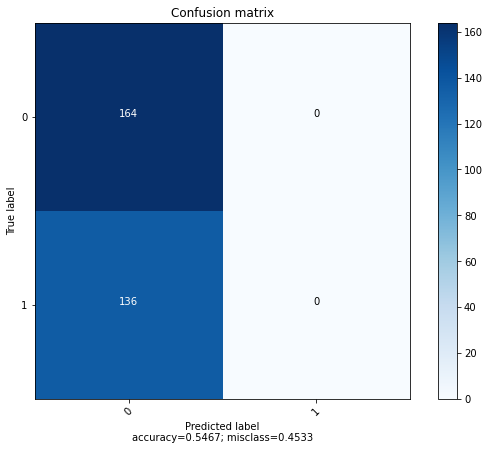

In [ ]:
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plot_confusion_matrix(cm)

Resposta

3)	Agora normalize os dados de entrada e treine novamente o modelo MLP. Avalie os resultados obtidos e comente o efeito da normalização no treinamento da Rede Neural.

Rascunho

In [ ]:
new_df = transform_data(dataset, normalize=True)
new_df.head()

,ESTC,NDEP,RENDA,TIPOR,VBEM,NPARC,VPARC,TEL,IDADE,RESMS,ENTRADA,target
0,0.333333,0.0,0.007792,0.0,0.003514,0.347826,0.003026,0.0,0.117647,0.114286,0.0,1
1,0.000000,0.0,0.006494,1.0,0.045405,0.391304,0.022693,0.0,0.274510,0.014286,0.0,1
2,0.000000,0.0,0.103896,0.0,0.142973,0.347826,0.113464,0.0,0.725490,0.114286,0.0,1
3,0.000000,0.0,0.350649,0.0,0.068108,0.478261,0.039334,1.0,0.235294,0.142857,0.0,1
4,0.333333,0.0,0.090909,0.0,0.137568,0.478261,0.092284,0.0,0.098039,0.016667,0.0,1


In [ ]:
X = new_df.values[:,:-1].astype('float')
target = new_df.values[:,-1]

encoder = LabelEncoder()
y = encoder.fit_transform(target)

n_input = X.shape[1]

if np.unique(y).shape[0] <= 2:
  print('Binary classification')
  n_output = 1

else:
  print('Multiclass classification')
  #y = to_categorical(y)
  n_output = encoder.classes_.shape[0]


X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train,y_train,test_size=0.2,random_state=42)

Binary classification


In [ ]:
if binary:
    train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).float().unsqueeze(1))
    val_dataset = CustomDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).float().unsqueeze(1))
    test_dataset = CustomDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).float().unsqueeze(1))
else:
    train_dataset = CustomDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).long())
    val_dataset = CustomDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).long())
    test_dataset = CustomDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test).long())

train_loader = DataLoader(dataset=train_dataset,batch_size=batch_size)
val_loader = DataLoader(dataset=val_dataset, batch_size=1)
test_loader = DataLoader(dataset=test_dataset, batch_size=1)

In [ ]:
model = NeuralNetwork(n_input = n_input, n_output=n_output,output_activation='sigmoid')
history, y_hat = train(model, train_loader, val_dataset, epochs=epochs, lr=lr, device=device, binary=binary)

  0%|          | 0/250 [00:00<?, ?it/s]

Epoch 001: | Train Loss: 0.684 | Val Loss: 0.6824 | Train Acc: 62.4667| Val Acc: 63.0000
Epoch 002: | Train Loss: 0.681 | Val Loss: 0.6798 | Train Acc: 64.2667| Val Acc: 64.0000
Epoch 003: | Train Loss: 0.678 | Val Loss: 0.6774 | Train Acc: 65.4333| Val Acc: 65.0000
Epoch 004: | Train Loss: 0.675 | Val Loss: 0.6753 | Train Acc: 66.0000| Val Acc: 64.0000
Epoch 005: | Train Loss: 0.673 | Val Loss: 0.6733 | Train Acc: 65.7667| Val Acc: 64.0000
Epoch 006: | Train Loss: 0.670 | Val Loss: 0.6713 | Train Acc: 65.6000| Val Acc: 65.0000
Epoch 007: | Train Loss: 0.668 | Val Loss: 0.6694 | Train Acc: 65.6333| Val Acc: 65.0000
Epoch 008: | Train Loss: 0.666 | Val Loss: 0.6674 | Train Acc: 66.2667| Val Acc: 66.0000
Epoch 009: | Train Loss: 0.663 | Val Loss: 0.6653 | Train Acc: 66.2667| Val Acc: 66.0000
Epoch 010: | Train Loss: 0.661 | Val Loss: 0.6632 | Train Acc: 66.3667| Val Acc: 67.0000
Epoch 011: | Train Loss: 0.658 | Val Loss: 0.6610 | Train Acc: 66.6000| Val Acc: 68.0000
Epoch 012: | Train Lo

Resposta

In [ ]:
y_pred = model.predict(test_dataset.X_data,binary=binary)


              precision    recall  f1-score   support

           0       0.86      0.97      0.91       164
           1       0.96      0.82      0.88       136

    accuracy                           0.90       300
   macro avg       0.91      0.89      0.90       300
weighted avg       0.91      0.90      0.90       300



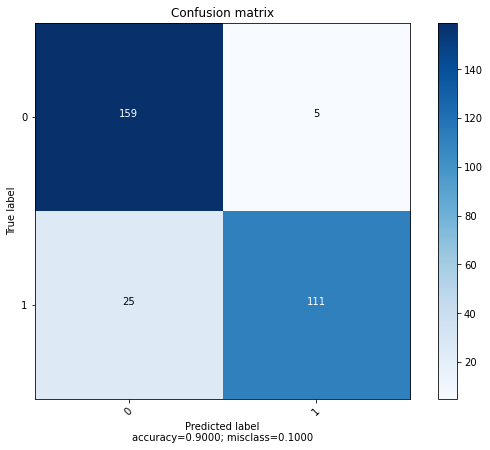

In [ ]:
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plot_confusion_matrix(cm)

## Parte 3 - Avaliando hiperparâmetros do modelo

1)	Modifique o tempo de treinamento (épocas) da Rede Neural. Escolha valores distintos (e.g. 1 e 1000 épocas) e avalie os resultados.

Rascunho

Resposta

2)	 Modifique a taxa de aprendizado da Rede Neural. Escolha valores distintos (e.g. 0,001 e 0,1) e avalie os resultados.

Rascunho

Resposta

3) Adicione o termo de *momentum* no algoritmo SGD. Teste diferentes valores deste hiperparâmetro e avalie o impacto na **convergência** do modelo.

Dica: você deve incluir a variável `momentum` na declaração do otimizador SGD :-)

Rascunho

Resposta

4)	Modifique a quantidade de neurônios na camada escondida da Rede Neural. Escolha valores distintos (e.g. 2 e 70 neurônios) e avalie os resultados.

Rascunho

Resposta

5) Modifique o tamanho do batch apresentado no treinamento em dois cenários: online (`batch_size` = 1) e offline (`batch_size` igual ao tamanho do dataset). Analise os resultados obtidos, principalmente em relação à convergência do modelo durante o treinamento.

Rascunho

Resposta

### Parte IV - Estratégias para aprimoramento de Redes Neurais.

Total: 4,0 pts.

1)	Implemente a técnica de parada antecipada (Early Stopping).

OBS: para essa questão, crie uma nova função (e.g., `train_ES`) baseada no `train`. Essa função pode ser encontrada neste [código](https://github.com/mdrs-thiago/PUC_Redes_Neurais/blob/main/pos_grad/lista%201/model_utils.py), inserindo a lógica da parada antecipada.

Rascunho

Resposta

2)	Faça novos testes para avaliar o desempenho da Rede Neural no problema designado usando a técnica K-Fold (com K = 10). Comente o resultado obtido.

Dica: não é necessário utilizar a ferramenta KFold do scikit-learn para o desenvolvimento deste item. Uma alternativa <b> simples </b> é fazer um *for loop*, selecionando os índices em bloco.

Rascunho

Resposta

3) Altere o **otimizador** do modelo de rede neural para algum de interesse (https://docs.pytorch.org/docs/stable/optim.html#algorithms). Execute em dois cenários: com e sem normalização. Avalie de que forma a mudança do otimizador altera o treinamento do modelo e sua generalização.

Rascunho

Resposta

4)	Faça análises e novas implementações que você julgue importante para o seu trabalho. Não esqueça de explicar a motivação da análise realizada.

Rascunho

Resposta